In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from scipy.optimize import curve_fit

from matplotlib.colors import LogNorm


import scienceplots

In [3]:
plt.style.use(['science','no-latex'])

In [4]:
data = np.loadtxt(f"g(2)_data/g2_Dot_-03239V_12964618_low_counts_1509.txt", skiprows=1)

In [5]:
def load_plot_RT_g2(filename):
    data = np.loadtxt(f"g(2)_data/{filename}", skiprows=1)
    t = data[:,0]
    counts = data[:,1]

    background_region = np.abs(t) > 8000  
    background = np.mean(counts[background_region])
    print(background)

    normalized_y_axis = counts / background
    
    plt.plot(data[:,0], normalized_y_axis)
    plt.xlim(0, 4000)
    plt.xlabel("time [ps]")
    plt.ylabel("counts")
    plt.show()

In [6]:
data_array = ["g2_Dot_-03239V_129646_etalon_0.25__uW_power_deadtime_5ns_20022026_100ps_bin_width.txt",
              "g2_Dot_-03239V_12964618_high_counts_2.txt",
              "g2_Dot_-03239V_12964618_high_counts.txt",
              "g2_Dot_-03239V_12964618_low_counts_1509.txt",
              "g2_Dot_-03239V_12964618_low_counts_1641.txt"]

63.04171632896305


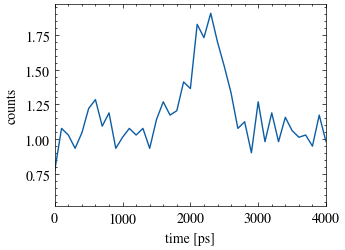

21766.27351821642


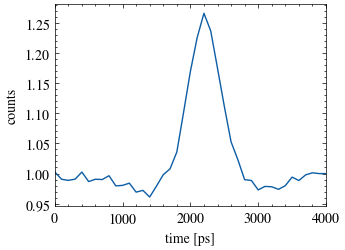

3488.713567839196


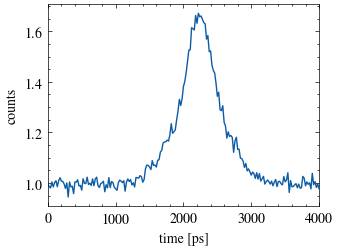

130.56257449344457


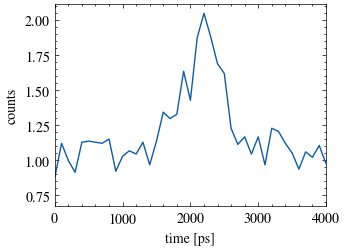

157.52562574493444


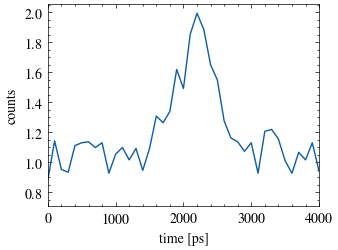

In [7]:
for i in data_array:
    load_plot_RT_g2(i)

In [8]:
def g2_fit_func_with_deph(tau, gamma, gamma_deph, beta):
    gamma_2 = gamma_deph + (gamma / 2)
    return 1 + (
        (
            gamma**2 * gamma_2 * (beta**4) * np.exp(-gamma * np.abs(tau) )
            - gamma * beta**2 * (2 * gamma_2 + (gamma * (beta - 2)) )**2 * np.exp(-gamma_2 * np.abs(tau) )
        )
        / (
            (gamma - gamma_2)
            * ( (2 * gamma_2) + (gamma * beta * (beta - 2)) )**2
        )  
    )

def g2_fit_func_simple(tau, gamma, beta):
    return np.exp(-gamma*np.abs(tau)) * (  ((beta**2) / (1-beta)**2) - (np.exp((gamma/2) * tau) ) )**2

In [9]:
data = np.loadtxt("g(2)_data/g2_Dot_-03239V_12964618_low_counts_1509.txt", skiprows=1) # g(2)_data/g2_Dot_-03239V_12964618_high_counts.txt
t = data[:,0]
counts = data[:,1]

In [10]:
background_region = np.abs(t) > 8000  
background = np.mean(counts[background_region])
print(background)
g2 = counts / background

center_index = np.argmax(g2)
t_center = t - t[center_index]

mask = np.abs(t_center) < 5000
t_fit = t_center[mask]
g2_fit_data = g2[mask]

130.56257449344457


In [11]:
sigma_y = np.sqrt(counts) / background
sigma_fit = sigma_y[mask]

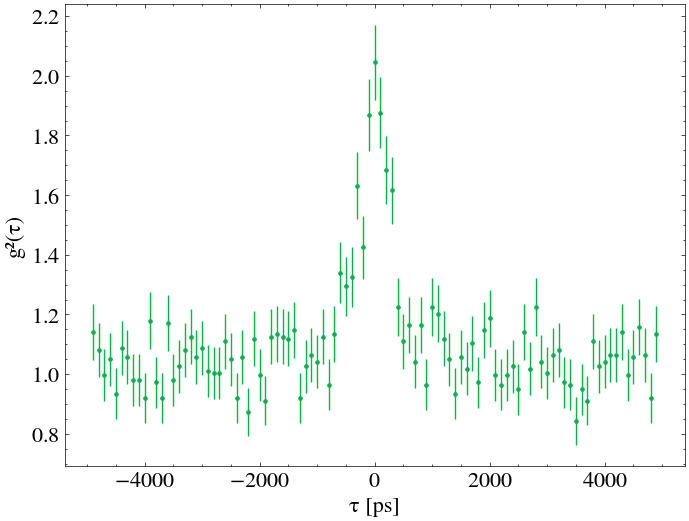

In [12]:

plt.figure(figsize=(8,6))
plt.plot(t_fit, g2_fit_data, '.', markersize=4)
plt.errorbar(t_fit, g2_fit_data, yerr = sigma_fit, fmt = ".", markersize = 4)
#plt.axvline(0, linestyle='--')  # check centering
plt.xlabel("τ [ps]", fontsize = 16)
plt.ylabel("g²(τ)", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
#plt.ylim(1.5,1.8)
#plt.xlim(-200, 200)
plt.show()

In [13]:
def normalize_and_plot(filename, save_filename):
    data = np.loadtxt(f"{filename}", skiprows=1) # g(2)_data/g2_Dot_-03239V_12964618_high_counts.txt
    t = data[:,0]
    counts = data[:,1]

    background_region = np.abs(t) > 8000  
    background = np.mean(counts[background_region])
    print(background)
    g2 = counts / background

    center_index = np.argmax(g2)
    t_center = t - t[center_index]

    mask = np.abs(t_center) < 5000
    t_fit = t_center[mask]
    g2_fit_data = g2[mask]

    
    sigma_y = np.sqrt(counts) / background
    sigma_fit = sigma_y[mask]

    
    plt.figure(figsize=(8,6))
    #plt.plot(t_fit, g2_fit_data, '.', markersize=4)
    plt.errorbar(t_fit, g2_fit_data, yerr = sigma_fit, fmt = ".", markersize = 4)
    plt.xlabel("τ [ps]", fontsize = 18)
    plt.ylabel("g²(τ)", fontsize = 18)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    plt.savefig(f"plots/{save_filename}.png", dpi = 300)
    plt.show()
    

3488.713567839196


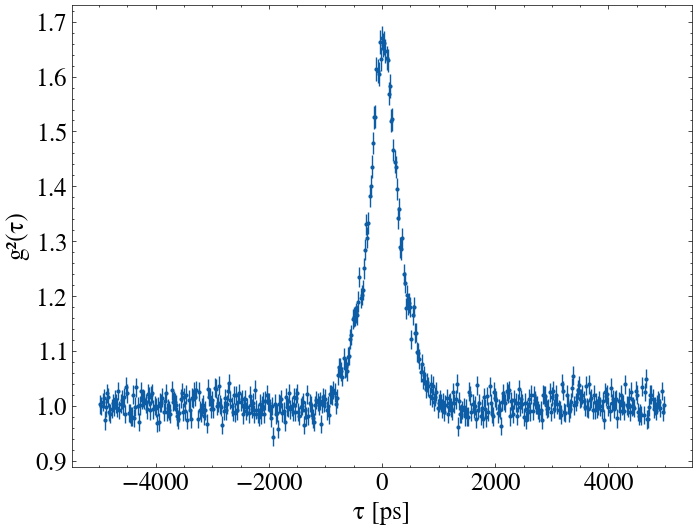

In [14]:
normalize_and_plot("g(2)_data/g2_Dot_-03239V_12964618_high_counts.txt", "g2_raw_high_power")

130.56257449344457


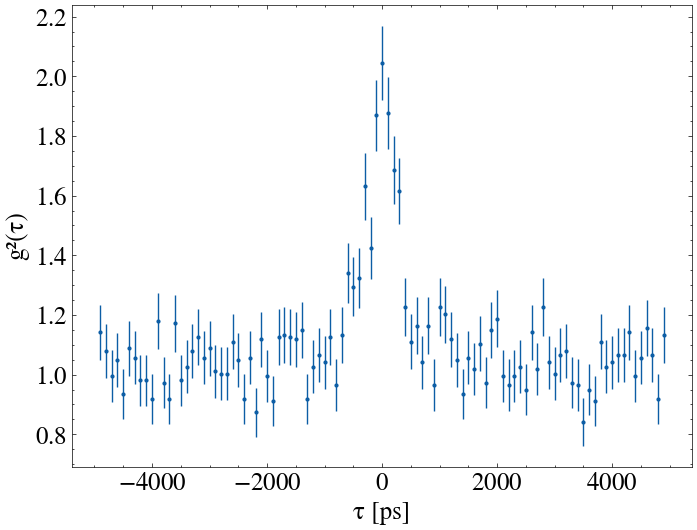

In [15]:
normalize_and_plot("g(2)_data/g2_Dot_-03239V_12964618_low_counts_1509.txt", "g2_raw_low_power")

In [16]:
def g2_fit_func(tau, gamma, beta, A, C):
    return A * (
        np.exp(-gamma * np.abs(tau)) *
        (((beta**2) / (1 - beta)**2) - np.exp((gamma / 2) * tau))**2
    ) + C

In [17]:
def g2_fit_func_normalized(tau, gamma, beta, A, C):
    g2_raw = np.exp(-gamma * np.abs(tau)) * (
        ((beta**2) / (1 - beta)**2) - np.exp((gamma / 2) * tau)
    )**2
    
    # Define "infinity" region (same as data)
    mask = np.abs(tau) > 3000
    
    # Avoid division by zero if mask is empty
    norm = np.mean(g2_raw[mask])
    print(norm)
    return g2_raw * norm

In [18]:
def g2_fit_func(tau, gamma, beta, A, C):
    return A * (
        np.exp(-gamma * np.abs(tau)) *
        (((beta**2) / (1 - beta)**2) - np.exp((gamma / 2) * tau))**2
    ) + C

gamma = 0.002864
gamma_deph = 0.0005567634444626606
beta  = 0.611098


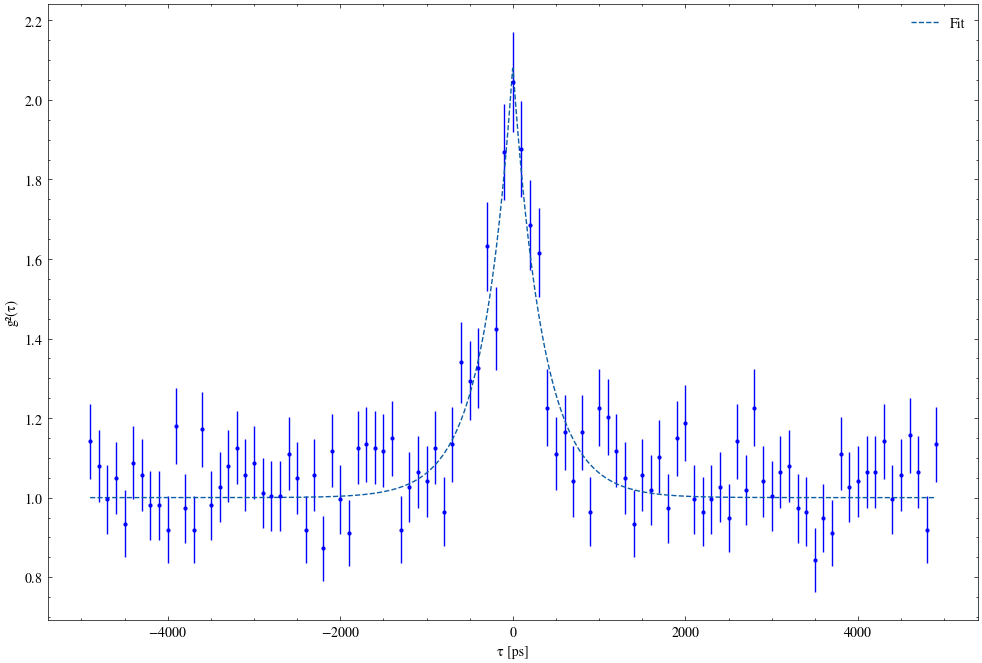

In [19]:
#initial_guess = [0.01, 0.01, 0.5]
initial_guess = [0.08, 0.0009, 0.80]


bounds = (
    [0.00, 0, 0],     # lower bounds: gamma>0, 0<beta<1, A>0, C~1
    [0.1, 0.1, 0.999]  # upper bounds
)

popt, pcov = curve_fit(
    g2_fit_func_with_deph,
    t_fit,
    g2_fit_data,
    sigma=sigma_fit,
    p0=initial_guess,
    bounds=bounds,
    maxfev=10000,
    absolute_sigma=True
)

gamma_fit, gamma_deph_fit, beta_fit = popt

print(f"gamma = {gamma_fit:.6f}")
print(f"gamma_deph = {gamma_deph_fit}")
print(f"beta  = {beta_fit:.6f}")


tau_smooth = np.linspace(min(t_fit), max(t_fit), 2000)
g2_smooth = g2_fit_func_with_deph(tau_smooth, gamma_fit, gamma_deph_fit, beta_fit)

plt.figure(figsize=(12,8))
#plt.plot(t_fit, g2_fit_data, 'b.', markersize=4, label='Data')
plt.errorbar(t_fit, g2_fit_data, yerr = sigma_fit, fmt = "b.", markersize = 4)
plt.plot(tau_smooth, g2_smooth, '--', linewidth=1, label='Fit')

plt.xlabel("τ [ps]")
plt.ylabel("g²(τ)")
#plt.title("g² Fit")
plt.legend() 
plt.show()

In [20]:
def convert_gamma_to_rate(gamma): # input will be ps, and output will be ns
    return 1/(gamma)  

convert_gamma_to_rate(gamma_fit)

349.18617253579737

In [21]:
# Trying to see what the transmission would be 
gamma = 0.006 #2.891
gamma_deph = 0.5#0.56
gamma_two = gamma_deph + (gamma / 2)
beta = 0.61
T = 1 - ((beta*gamma*gamma_two * (2-beta)) / (2*(gamma_two**2)))
print(T)
rabi = 0.1

def transmission(detuning, beta, gamma, gamma_deph):
    gamma_two = gamma_deph + (gamma / 2)
    return 1 - ((beta*gamma*gamma_two * (2-beta)) / (2*(gamma_two**2 + detuning**2 + 4* (gamma_two/gamma)*rabi**2)))

0.9949429423459244


Making function and saving plots! 

In [22]:
def load_and_fit_g2(filename, save_filename, color_fit):
    data = np.loadtxt(f"{filename}", skiprows=1) 
    t = data[:,0]
    counts = data[:,1]
    background_region = np.abs(t) > 8000  
    background = np.mean(counts[background_region])

    g2 = counts / background

    center_index = np.argmax(g2)
    t_center = t - t[center_index]

    mask = np.abs(t_center) < 4000
    t_fit = t_center[mask]
    g2_fit_data = g2[mask]

    sigma_y = np.sqrt(counts) / background
    sigma_fit = sigma_y[mask]

    initial_guess = [5.4*10**(-3), 1.2*10**(-3), 0.8] # [0.006, 0.0005, 0.8]

    bounds = (
        [0.0, 0.0, 0.0], # gamma, gamma_deph, beta     
        [1.0, 1.0, 1.0]  
    )

    popt, pcov = curve_fit(
        g2_fit_func_with_deph,
        t_fit,
        g2_fit_data,
        sigma=sigma_fit,
        p0=initial_guess,
        bounds=bounds,
        maxfev=10000,
        absolute_sigma=True
    )

    gamma_fit, gamma_deph_fit, beta_fit = popt

    print("gamma:", gamma_fit*1e3)
    print("gamma_deph:", gamma_deph_fit*1e3)
    print("beta:",beta_fit)
    ###errors

    perr = np.sqrt(np.diag(pcov))
    print(perr[0]*1e3)
    print(perr[1]*1e3)
    print(perr[2])

    Gamma_fit = (gamma_fit*1e3)/ (2*np.pi)
    Gamma_deph_fit = (gamma_deph_fit*1e3) / (2*np.pi)

    tau_smooth = np.linspace(min(t_fit), max(t_fit), 2000)
    g2_smooth = g2_fit_func_with_deph(tau_smooth, gamma_fit, gamma_deph_fit, beta_fit)
    g2_guess = g2_fit_func_with_deph(tau_smooth, *initial_guess)

    plt.figure(figsize=(10,6))
    #plt.plot(t_fit, g2_fit_data, 'b.', markersize=4, label='Data')
    plt.errorbar(t_fit, g2_fit_data, yerr = sigma_fit, fmt = ".", markersize = 4, color = color_fit)
    

    textstr = (
    rf"$\Gamma = {Gamma_fit:.3f}$ (GHz)"
    "\n"
    rf"$\Gamma_{{deph}} = {Gamma_deph_fit:.3f}$ (GHz)"
    "\n"
    rf"$\beta = {beta_fit:.3f}$"
    )

    plt.text(
    0.05, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top'
    )
    plt.plot(tau_smooth, g2_smooth, '--', linewidth=1, color = color_fit)
    #plt.plot(tau_smooth, g2_guess, linewidth = 1, color = "red", label = "guess")
    plt.xlabel("τ [ps]", fontsize = 16)
    plt.ylabel("g²(τ)", fontsize = 16)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    #plt.legend(prop = {"size": 20}) 
    #plt.savefig(f"plots/{save_filename}.png", dpi = 300)
    plt.show()

    return gamma_fit*1e3, gamma_deph_fit*1e3, beta_fit, t_fit, g2_fit_data

gamma: 1.6080312134367993
gamma_deph: 1.8545967708249282
beta: 0.881522677142367
0.10708249017328432
0.04119122212643249
0.03232002730875646


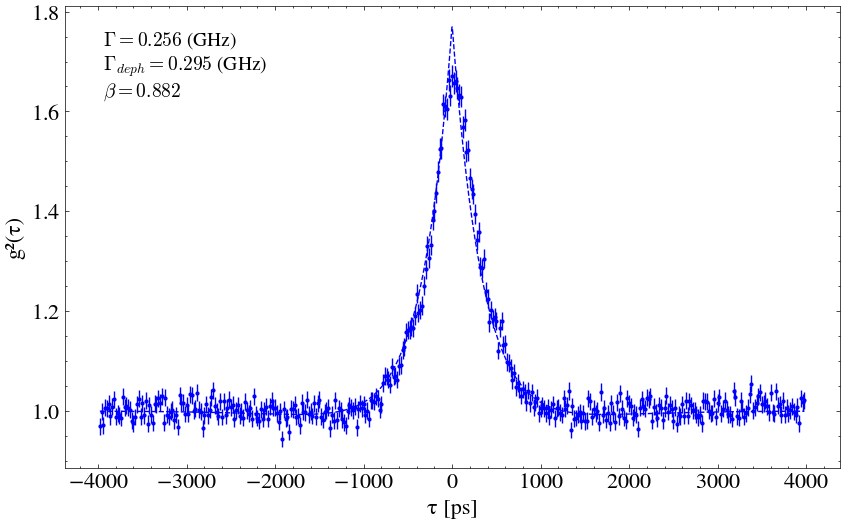

In [23]:
gamma_fit_high_power, gamma_deph_fit_high_power, beta_high_power, t_norm_high_power, g2_norm_high_power = load_and_fit_g2("g(2)_data/g2_Dot_-03239V_12964618_high_counts.txt", "g2_high_power", color_fit="blue")

gamma: 1.0573693984759762
gamma_deph: 3.4614303279272893
beta: 0.9999999999999999
0.16249780370730274
0.09376574713578494
0.08181902651730277


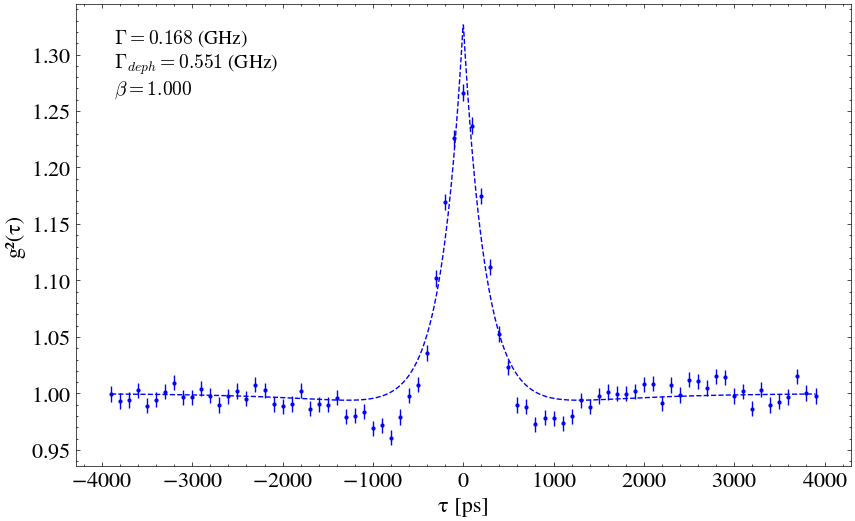

In [24]:
gamma_fit_high_power_2, gamma_deph_fit_high_power_2, beta_high_power_2, t_norm_high_power_2, g2_norm_high_power_2 = load_and_fit_g2("g(2)_data/g2_Dot_-03239V_12964618_high_counts_2.txt", "g2_high_power_2", color_fit="blue")

gamma: 3.126198604626686
gamma_deph: 0.6245731687610214
beta: 0.6002242477034063
2.7373564262301935
1814.5573417182377
145.45589991363747


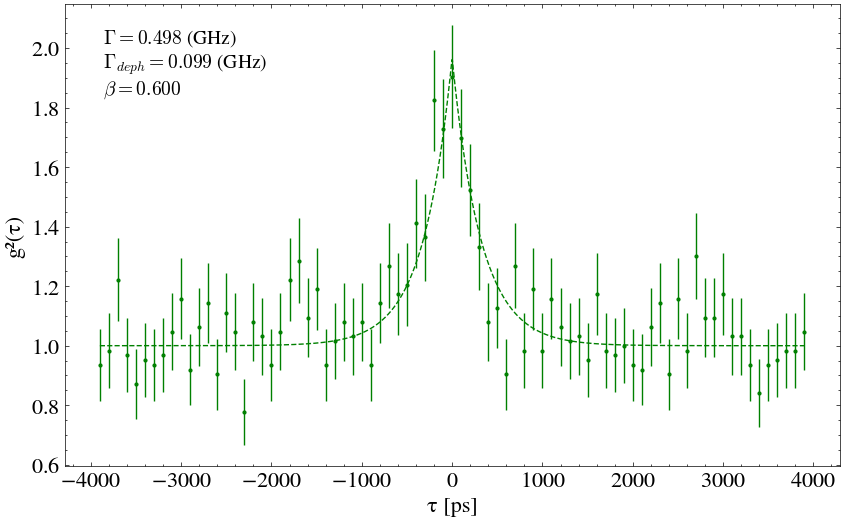

In [25]:
gamma_fit_low_power, gamma_deph_fit_low_power, beta_low_power, t_norm_low_power, g2_norm_low_power = load_and_fit_g2("g(2)_data/g2_Dot_-03239V_129646_etalon_0.25__uW_power_deadtime_5ns_20022026_100ps_bin_width.txt", "g2_low_power", color_fit = "green")

gamma: 2.8638933032395237
gamma_deph: 0.5568801683295418
beta: 0.6111101559959092
1.4859923413428449
15960.326630858797
1592.2626183660852


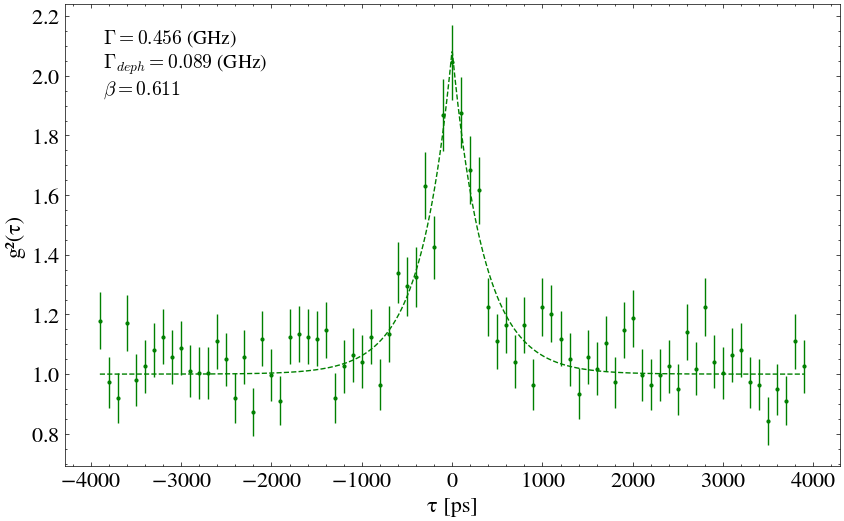

In [26]:
gamma_fit_low_power_2, gamma_deph_fit_low_power_2, beta_low_power_2, t_norm_low_power_2, g2_norm_low_power_2 = load_and_fit_g2("g(2)_data/g2_Dot_-03239V_12964618_low_counts_1509.txt", "g2_low_power_2", color_fit = "green")

gamma: 2.890730164735781
gamma_deph: 0.5630425674802032
beta: 0.6104595545867131
1.379078697125131
12282.268430783828
1204.8316940539264


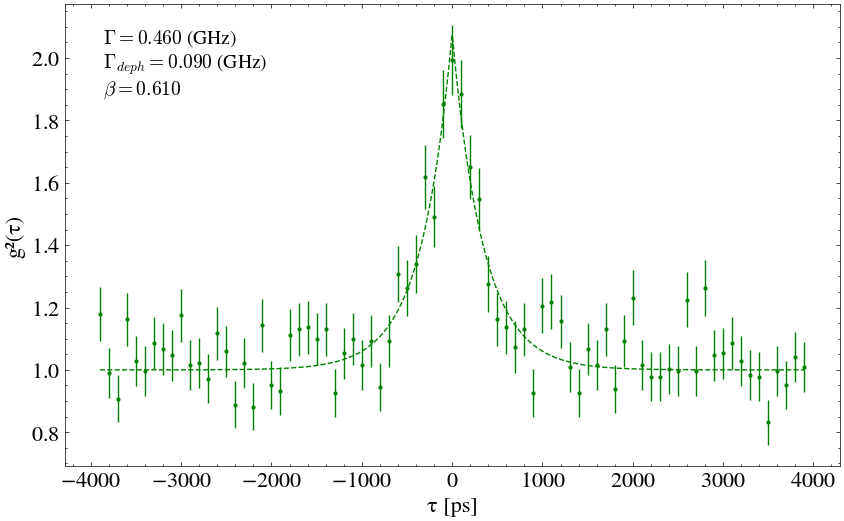

In [27]:
gamma_fit_low_power_3, gamma_deph_fit_low_power_3, beta_low_power_3, t_norm_low_power_3, g2_norm_low_power_3 = load_and_fit_g2("g(2)_data/g2_Dot_-03239V_12964618_low_counts_1641.txt", "g2_high_power_3", color_fit = "green")

In [28]:
def transmission_plot(gamma_fit, gamma_deph_fit, beta_fit, save_filename, color_fit):
    def transmission(detuning, beta, gamma, gamma_deph):
        gamma_two = gamma_deph + (gamma / 2)
        return 1 - ((beta*gamma*gamma_two * (2-beta)) / (2*(gamma_two**2 + detuning**2 + 4* (gamma_two/gamma)*rabi**2)))
    
    detuning = np.linspace(-6,6,10000)

    plt.figure(figsize = (10,6))
    plt.plot(detuning, transmission(detuning, beta_fit, gamma_fit, gamma_deph_fit), color = color_fit)
    plt.xlabel("Detuning (GHz)", fontsize = 16)
    plt.ylabel("g²(τ)", fontsize = 16)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    #plt.legend(prop = {"size": 20}) 
    plt.savefig(f"plots/{save_filename}.png", dpi = 300)
    plt.show() 

In [29]:
#transmission_plot(gamma_fit_low_power, gamma_deph_fit_low_power, beta_fit, "transmission_low_power", "green")

In [30]:
#transmission_plot(gamma_fit_high_power, gamma_deph_fit_high_power, beta_fit, "transmission_high_power", color_fit = "blue")

In [31]:
#transmission_plot(gamma_fit_high_power_2, gamma_deph_fit_high_power_2, beta_high_power_2, "transmission_high_power", color_fit = "blue")

In [32]:
# Let's do them on top of each other 

#plt.figure(figsize = (8,6))
#plt.plot(detuning, transmission(detuning, beta_low_power, gamma_fit_low_power, gamma_deph_fit_low_power), label = r"$P \approx 0$", color = "green")
#plt.plot(detuning, transmission(detuning, beta_high_power, gamma_fit_high_power, gamma_deph_fit_high_power), label = r"$P \approx P_{sat}$", color = "blue")
#plt.xlabel("Detuning $\Delta$  (GHz)", fontsize = 16)
#plt.ylabel("Transmission", fontsize = 16)
#plt.xticks(fontsize = 16)
#plt.yticks(fontsize = 16)
#plt.legend(prop = {"size": 20}) 
#plt.savefig(f"plots/double_transmission.png", dpi = 300)
#plt.show()

In [33]:
# Running the g2 with a power dependence

In [34]:
def g2_fit_func_with_power_dependence(tau, gamma, gamma_deph, beta, S):
    gamma_2 = gamma_deph + (gamma / 2)
    return 1 + (
        (
            gamma**2 * gamma_2 * (beta**4) * np.exp(-gamma * np.abs(tau) )
            - gamma * beta**2 * (2 * gamma_2 + (gamma * (beta - 2)) )**2 * np.exp(-gamma_2 * np.abs(tau) )
        )   
        / (
            (gamma - gamma_2)
            * ( (2 * gamma_2) + (gamma * beta * (beta - 2)) )**2
         *(np.sqrt(1 + S))) 
    )

In [35]:
def load_and_fit_g2_with_power_dependence(filename, save_filename, color_fit):
    data = np.loadtxt(f"{filename}", skiprows=1) 
    t = data[:,0]
    counts = data[:,1]
    background_region = np.abs(t) > 8000  
    background = np.mean(counts[background_region])

    g2 = counts / background

    center_index = np.argmax(g2)
    t_center = t - t[center_index]

    mask = np.abs(t_center) < 4000
    t_fit = t_center[mask]
    g2_fit_data = g2[mask]

    sigma_y = np.sqrt(counts) / background
    sigma_fit = sigma_y[mask]

    initial_guess = [5.4*10**(-3), 1.2*10**(-3), 0.5, 0.2] # 3.5*10**(-3), 0.60*10**(-3), 0.6, 1.2

    bounds = (
        [0.0, 0.0, 0.0, 0.0], # gamma, gamma_deph, beta     
        [5, 5, 1.0, 100]  
    )

    popt, pcov = curve_fit(
        g2_fit_func_with_power_dependence,
        t_fit,
        g2_fit_data,
        sigma=sigma_fit,
        p0=initial_guess,
        bounds=bounds,
        maxfev=10000,
        absolute_sigma=True
    )

    gamma_fit, gamma_deph_fit, beta_fit, S_power = popt

    print("gamma:", gamma_fit*1e3)
    print("gamma_deph:", gamma_deph_fit*1e3)
    print("beta:",beta_fit)
    print("S:", S_power)
    ###errors

    perr = np.sqrt(np.diag(pcov))
    print(perr[0]*1e3)
    print(perr[1]*1e3)
    print(perr[2])

    Gamma_fit = (gamma_fit*1e3)/ (2*np.pi)
    Gamma_deph_fit = (gamma_deph_fit*1e3) / (2*np.pi)

    tau_smooth = np.linspace(min(t_fit), max(t_fit), 2000)
    g2_smooth = g2_fit_func_with_power_dependence(tau_smooth, gamma_fit, gamma_deph_fit, beta_fit, S_power)
    g2_guess = g2_fit_func_with_power_dependence(tau_smooth, *initial_guess)

    plt.figure(figsize=(10,6))
    #plt.plot(t_fit, g2_fit_data, 'b.', markersize=4, label='Data')
    plt.errorbar(t_fit, g2_fit_data, yerr = sigma_fit, fmt = ".", markersize = 4, color = color_fit)
    

    textstr = (
    rf"$\Gamma = {Gamma_fit:.3f}$ (GHz)"
    "\n"
    rf"$\Gamma_{{deph}} = {Gamma_deph_fit:.3f}$ (GHz)"
    "\n"
    rf"$\beta = {beta_fit:.3f}$"
    )

    plt.text(
    0.05, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top'
    )
    plt.plot(tau_smooth, g2_smooth, '--', linewidth=1, color = color_fit)
    plt.plot(tau_smooth, g2_guess, linewidth = 1, color = "red", label = "guess")
    plt.xlabel("τ [ps]", fontsize = 16)
    plt.ylabel("g²(τ)", fontsize = 16)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    #plt.legend(prop = {"size": 20}) 
    #plt.savefig(f"plots/{save_filename}.png", dpi = 300)
    plt.show()

    return gamma_fit*1e3, gamma_deph_fit*1e3, beta_fit, t_fit, g2_fit_data

gamma: 3.1262604769768374
gamma_deph: 0.6182836336824877
beta: 0.6045561819812226
S: 0.09653176110340189
2.747096309123702
154944.83259046954
104261.2867401866


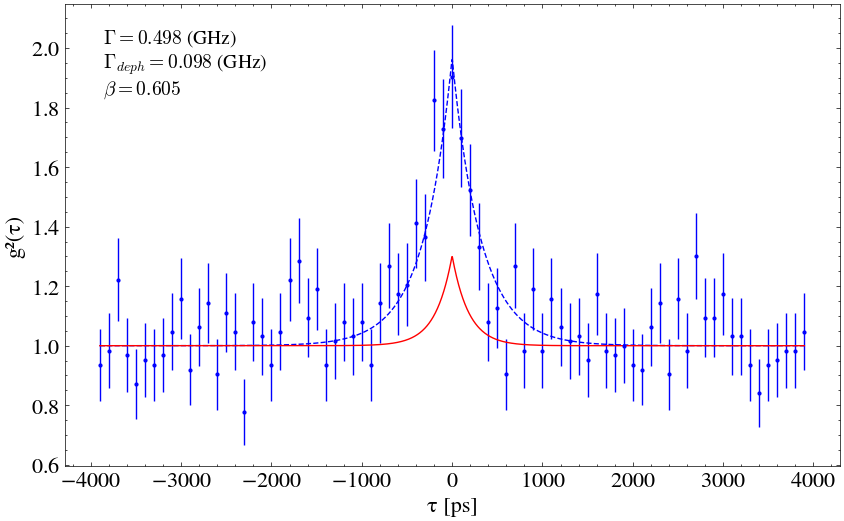

In [36]:
gamma_fit_low_power_power_dep, gamma_deph_fit_low_power_power_dep, beta_low_power_power_dep, t_norm_low_power_power_dep, g2_norm_low_power_power_dep = load_and_fit_g2_with_power_dependence("g(2)_data/g2_Dot_-03239V_129646_etalon_0.25__uW_power_deadtime_5ns_20022026_100ps_bin_width.txt", "g2_low_power_power_dependence", color_fit="blue")

gamma: 2.623206653138655
gamma_deph: 0.2609262570204745
beta: 0.56945987506043
S: 1.2243058769751975e-09
0.32856080926295816
0.7007072947969982
0.5239378166449191


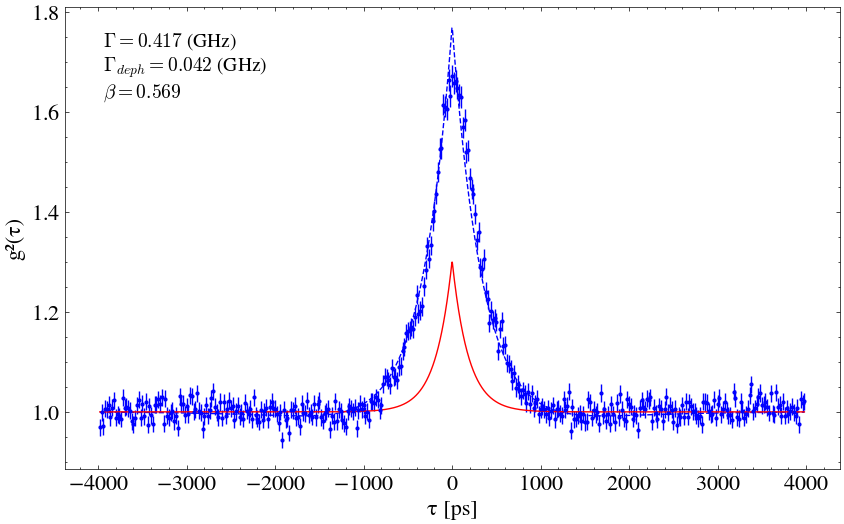

In [37]:
gamma_fit_high_power_power_dep, gamma_deph_fit_high_power_power_dep, beta_high_power_power_dep, t_norm_high_power_power_dep, g2_norm_high_power_power_dep = load_and_fit_g2_with_power_dependence("g(2)_data/g2_Dot_-03239V_12964618_high_counts.txt", "g2_high_power_2_power_dependence", color_fit="blue")

In [38]:
# Trying to use the three low count g2's to get errors by the spread

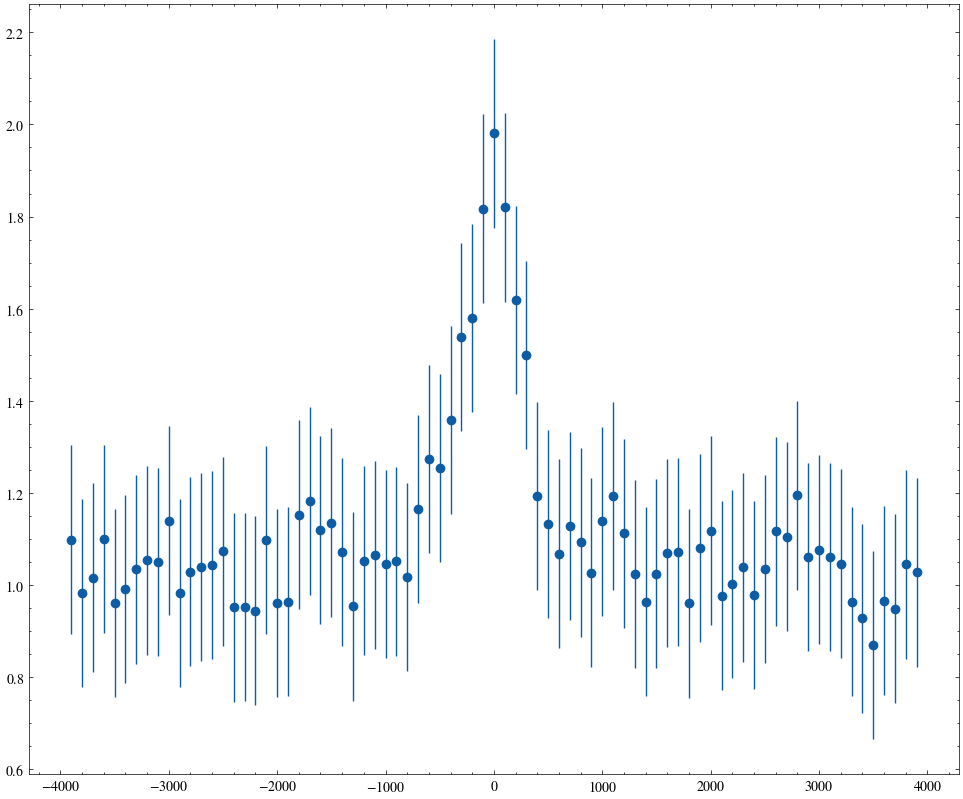

In [39]:
data1 = np.loadtxt("g(2)_data/g2_Dot_-03239V_12964618_low_counts_1641.txt", skiprows=1)
data2 = np.loadtxt("g(2)_data/g2_Dot_-03239V_12964618_low_counts_1509.txt", skiprows=1)
data3 = np.loadtxt("g(2)_data/g2_Dot_-03239V_129646_etalon_0.25__uW_power_deadtime_5ns_20022026_100ps_bin_width.txt", skiprows=1)
#t = data1[:,0]  # assume same time axis
c1 = data1[:,1]
c2 = data2[:,1]
c3 = data3[:,1]

t1 = data1[:,0]
t2 = data2[:,0]
t3 = data3[:,0]


counts_stack = np.vstack([g2_norm_low_power, g2_norm_low_power_2, g2_norm_low_power_3])

mean = np.mean(counts_stack, axis = 0)
sigma_y = np.std(mean)


#sigma_y  = counts_std

plt.figure(figsize = (12,10))
plt.errorbar(t_norm_low_power, mean, sigma_y, fmt = "o")
plt.show()


Trying bootstrapping method to see if the fit is robust to small perturbations in the data.

In [41]:
def plot_histograms(params):
    gamma, gamma_deph, beta = params.T

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].hist(gamma, bins=50)
    axs[0].set_title("Gamma")

    axs[1].hist(gamma_deph, bins=50)
    axs[1].set_title("Gamma_deph")

    axs[2].hist(beta, bins=50)
    axs[2].set_title("Beta")

    plt.show()

In [42]:
def load_data(filename):
    data = np.loadtxt(filename, skiprows=1)
    t = data[:, 0]
    counts = data[:, 1]
    return t, counts

In [43]:
def preprocess(t, counts):
    # Estimate background from far-away region
    background_region = np.abs(t) > 8000
    background = np.mean(counts[background_region])

    # Normalize to get g2
    g2 = counts / background

    # Center the data at the peak
    center_index = np.argmax(g2)
    t_center = t - t[center_index]

    # Define fitting window
    mask = np.abs(t_center) < 4000

    return t_center, g2, counts, background, mask

In [44]:
def plot_correlations(params):
    gamma, gamma_deph, beta = params.T

    plt.figure(figsize=(6,5))
    plt.scatter(gamma, gamma_deph, alpha=0.3, s=5)
    plt.xlabel("gamma")
    plt.ylabel("gamma_deph")
    plt.show()

In [45]:
def plot_3d(params, filename_save):

    gamma, gamma_deph, beta = params.T

    fig = plt.figure(figsize = (14, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(gamma*1e3, gamma_deph*1e3, beta, s=6, alpha=0.2)
    ax.view_init(elev=20)
    ax.set_xlabel(r"$\gamma$", fontsize = 14)
    ax.set_ylabel(r"$\gamma_{\mathrm{deph}}$", fontsize = 14)
    ax.set_zlabel(r"$\beta$", fontsize = 14)
    ax.grid(True, alpha=0.3)
    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
    ax.set_box_aspect(None, zoom=0.90)
    plt.savefig(f"plots/{filename_save}.png", dpi = 300)
    plt.show()

In [46]:
def plot_fits(results, n_plot=100):
    t_fit = results["t_fit"]
    g2_fit = results["g2_fit"]
    fits = results["fits"]
    popt = results["popt"]

    plt.scatter(t_fit, g2_fit, s=10, color='black')

    if len(fits) > 0:
        idx = np.random.choice(len(fits), size=min(n_plot, len(fits)), replace=False)
        for i in idx:
            plt.plot(t_fit, fits[i], color='blue', alpha=0.1)

    plt.plot(t_fit, g2_fit_func_with_deph(t_fit, *popt), color='red', lw=2)

    plt.show()

In [47]:
def run_bootstrap_fit(filename, n_boot=10000):

    t, counts = load_data(filename)
    t_center, g2, counts_raw, background, mask = preprocess(t, counts)

    t_fit = t_center[mask]
    g2_fit = g2[mask]
    sigma_fit = np.sqrt(counts_raw[mask]) / background

    initial_guess = [0.006, 0.0005, 0.6]
    bounds = ([0, 0, 0], [1, 1, 1])

    popt, _ = curve_fit(
        g2_fit_func_with_deph,
        t_fit,
        g2_fit,
        sigma=sigma_fit,
        p0=initial_guess,
        #bounds=bounds,
        maxfev=10000,
        absolute_sigma=True
    )

    model_counts = g2_fit_func_with_deph(t_fit, *popt) * background # Making an array of count from our first fit, the PDF if you will 
    params = []
    fits = []

    for _ in range(n_boot):
        counts_sim = np.random.poisson(model_counts) # Sampling randomly from our distribution made from the intial g2
        g2_sim = counts_sim / background
        try:
            popt_sim, _ = curve_fit(
                g2_fit_func_with_deph,
                t_fit,
                g2_sim,
                sigma=sigma_fit,
                p0=popt,
                bounds=bounds,
                maxfev=10000
            )

            params.append(popt_sim)
            fits.append(g2_fit_func_with_deph(t_fit, *popt_sim))

        except RuntimeError:
            continue

    params = np.array(params)
    fits = np.array(fits)

    return {
        "t_fit": t_fit,
        "g2_fit": g2_fit,
        "popt": popt,
        "params": params,
        "fits": fits
    }

In [50]:
def plot_gamma_vs_gamma_deph(params):
    gamma = params[:, 0]
    gamma_deph = params[:, 1]

    plt.figure(figsize=(6,5))
    plt.scatter(gamma*1e3, gamma_deph*1e3, s=8, alpha=0.3)

    plt.xlabel("gamma")
    plt.ylabel("gamma_deph")
    plt.title("Correlation: gamma vs gamma_deph")

    plt.show()

In [51]:
#plot_gamma_vs_gamma_deph(results["params"])

In [52]:
def plot_gamma_vs_gamma_deph_density(params, filename_save):
    gamma = params[:, 0]
    gamma_deph = params[:, 1]

    plt.figure(figsize=(8,6))

    hb = plt.hexbin(
        gamma*1e3,
        gamma_deph*1e3,
        gridsize=40,
        cmap='Blues',
        norm=LogNorm()   
    )
    plt.xlabel(r"$\gamma$", fontsize = 16)
    plt.ylabel(r"$\gamma_{\mathrm{deph}}$", fontsize = 16)
    #plt.title("Log-density: gamma vs gamma_deph")

    cb = plt.colorbar(hb)
    cb.set_label("log(counts)", fontsize = 16)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    plt.savefig(f"plots/{filename_save}.png", dpi = 300)
    plt.show()

In [53]:
#plot_gamma_vs_gamma_deph_density(results["params"], "2d_heatmap_log")

In [54]:
results_high_counts = run_bootstrap_fit("g(2)_data/g2_Dot_-03239V_12964618_high_counts.txt")

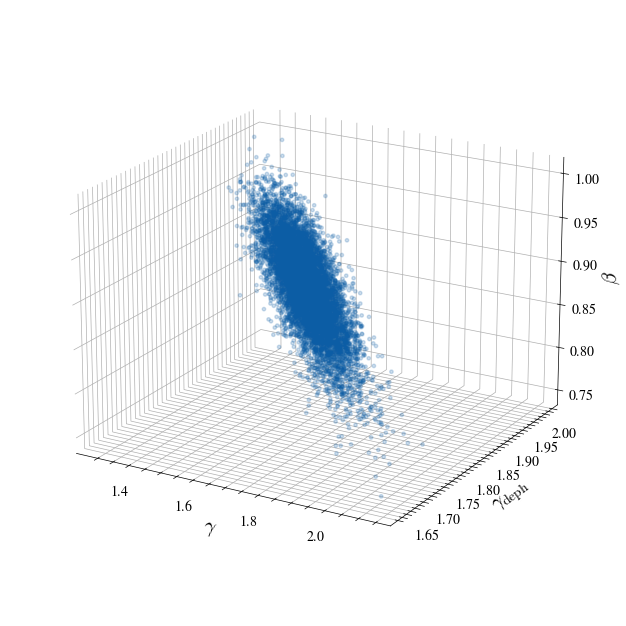

In [55]:
plot_3d(results_high_counts["params"], "3d_bootstraping_results_high_counts")

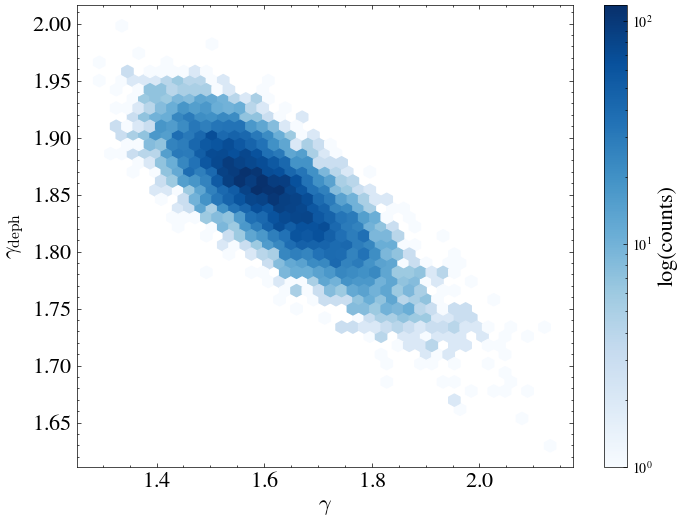

In [56]:
plot_gamma_vs_gamma_deph_density(results_high_counts["params"], "2d_heatmap_log_high_counts")

In [57]:
results_high_counts_2 = run_bootstrap_fit("g(2)_data/g2_Dot_-03239V_12964618_high_counts.txt")

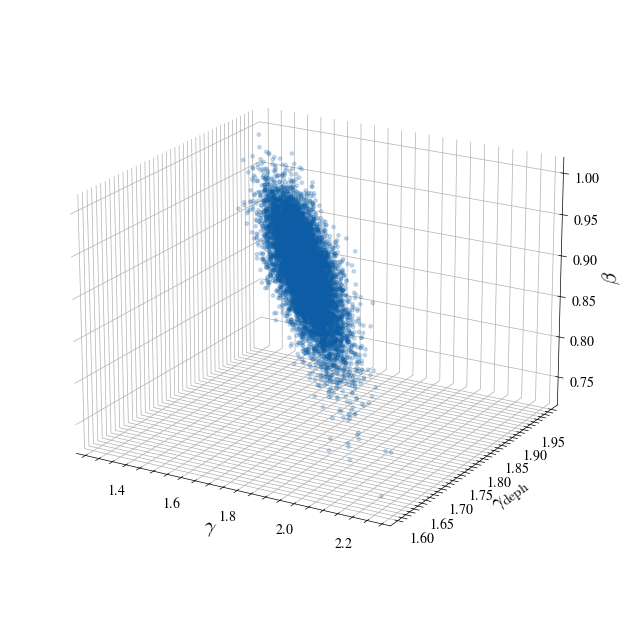

In [58]:
plot_3d(results_high_counts_2["params"], "3d_bootstraping_results_high_counts_2")